# Library

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler 
from sklearn.metrics import mean_squared_error, mean_absolute_error,  mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns

# Load File

In [2]:
folder = r'C:\Users\User\Documents\Bismillah'
tahun_data = [2020, 2021, 2022, 2023, 2024]
list_df = []

for tahun in tahun_data:
    path = os.path.join(folder, f'{tahun} Summary.xlsx')
    df = pd.read_excel(path)
    df['Tahun'] = tahun
    list_df.append(df)

df_all = pd.concat(list_df, ignore_index=True)

# EDA

In [3]:
print("--- Dataset Info ---")
print(df_all.info(), '\n')

print("--- Missing Values per Column ---")
print(df_all.isnull().sum(), '\n')

print("--- Duplicate Rows ---")
print(df_all.duplicated().sum(), '\n')


if df_all.duplicated().any():
    df_all = df_all.drop_duplicates()
    print("Duplicates dropped, new shape:", df_all.shape)


numeric_cols = df_all.select_dtypes(include=['float64', 'int64'])
print("--- Correlation Matrix ---")
print(numeric_cols.corr(), '\n')

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 31 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Vendor        318 non-null    object 
 1   Brand         313 non-null    object 
 2   JanQty        310 non-null    float64
 3   JanNet Sales  310 non-null    float64
 4   FebQty        310 non-null    float64
 5   FebNet Sales  310 non-null    object 
 6   MarQty        312 non-null    float64
 7   MarNet Sales  312 non-null    object 
 8   AprQty        308 non-null    float64
 9   AprNet Sales  308 non-null    object 
 10  JunQty        311 non-null    float64
 11  JunNet Sales  311 non-null    object 
 12  JulQty        310 non-null    float64
 13  JulNet Sales  310 non-null    object 
 14  AgtQty        308 non-null    float64
 15  AgtNet Sales  307 non-null    object 
 16  SepQty        308 non-null    float64
 17  SepNet Sales  307 non-null    object 
 18  OktQty   

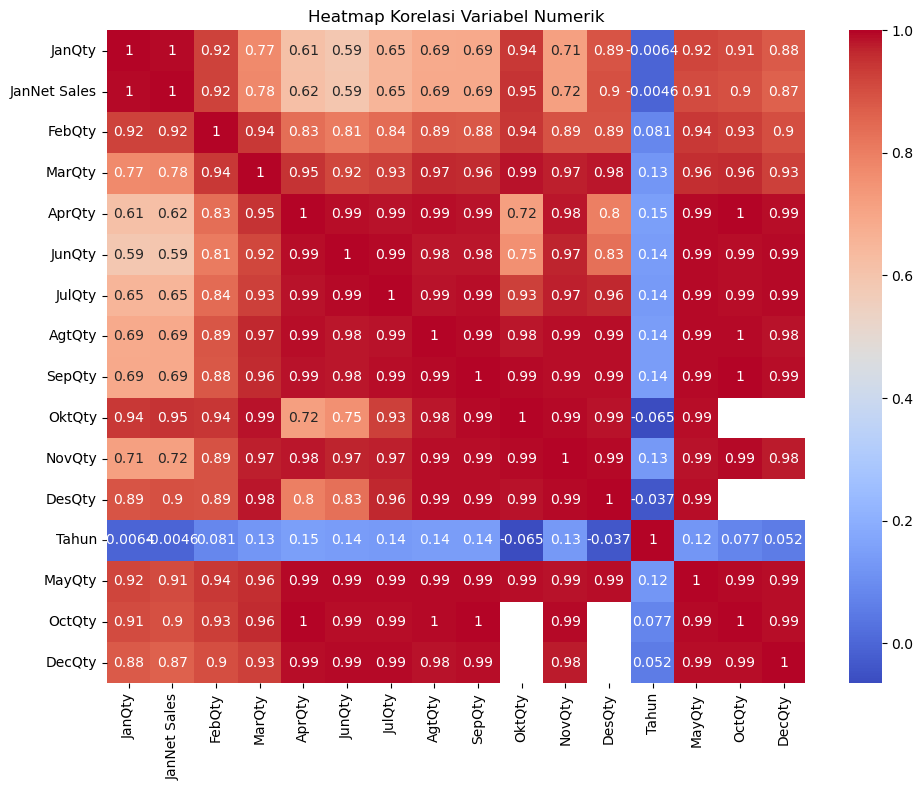

In [4]:
plt.figure(figsize=(10,8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Heatmap Korelasi Variabel Numerik")
plt.tight_layout()
plt.show()

# Konversi Data Penjualan Ke Format Time Series (Long Format)

In [5]:
bulan_nama = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Agt','Sep','Okt','Nov','Des']
records = []
for _, row in df_all.iterrows():
    for i, b in enumerate(bulan_nama, start=1):
        # Cek variasi nama kolom dengan atau tanpa spasi
        col1 = f'{b}Net Sales'
        col2 = f'{b} Net Sales'
        if col1 in df_all.columns:
            col = col1
        elif col2 in df_all.columns:
            col = col2
        else:
            col = None
        
        if col is not None:
            val = row.get(col, np.nan)
            if pd.notna(val):
                try:
                    clean_val = float(str(val).replace(',','').strip())
                    records.append({'Tahun': row['Tahun'], 'Bulan': i, 'Penjualan_Bersih': clean_val})
                except:
                    pass

df_ts = pd.DataFrame(records)
df_ts['Tanggal'] = pd.to_datetime(df_ts['Tahun'].astype(str) + '-' + df_ts['Bulan'].astype(str) + '-01')

df_monthly = df_ts.groupby('Tanggal')['Penjualan_Bersih'].sum().reset_index()

print("Missing in time series:", df_monthly.isnull().sum(), '\n')
print("Duplicates in TS:", df_monthly.duplicated().sum(), '\n')
print(df_monthly[['Tanggal', 'Penjualan_Bersih']].head(10))  # tampilkan 10 baris pertama


df_monthly['Bulan'] = df_monthly['Tanggal'].dt.month
df_monthly['Lag_1'] = df_monthly['Penjualan_Bersih'].shift(1)
df_monthly = df_monthly.dropna().reset_index(drop=True)

Missing in time series: Tanggal             0
Penjualan_Bersih    0
dtype: int64 

Duplicates in TS: 0 

     Tanggal  Penjualan_Bersih
0 2020-01-01      2.485500e+10
1 2020-02-01      1.048432e+10
2 2020-03-01      5.920911e+09
3 2020-04-01      1.650581e+09
4 2020-06-01      1.547015e+09
5 2020-07-01      2.851217e+09
6 2020-08-01      3.987961e+09
7 2020-09-01      4.440590e+09
8 2020-10-01      4.572613e+09
9 2020-11-01      5.247716e+09


In [6]:
df_monthly_sorted = df_monthly.sort_values('Tanggal').reset_index(drop=True)

train_size_80 = int(len(df_monthly_sorted) * 0.8)
train_80 = df_monthly_sorted.iloc[:train_size_80]
test_20 = df_monthly_sorted.iloc[train_size_80:]

print("Pembagian 80:20 berdasarkan urutan waktu:")
print("Jumlah data train:", len(train_80))
print("Jumlah data test:", len(test_20))

Pembagian 80:20 berdasarkan urutan waktu:
Jumlah data train: 41
Jumlah data test: 11


# Preprocessing

In [23]:
# Cek missing dan duplikasi
print("Missing in time series:", df_monthly.isnull().sum(), '\n')
print("Duplicates in TS:", df_monthly.duplicated().sum(), '\n')

# Buat fitur tambahan
df_monthly['Bulan'] = df_monthly['Tanggal'].dt.month
df_monthly['Lag_1'] = df_monthly['Penjualan_Bersih'].shift(1)
df_monthly = df_monthly.dropna().reset_index(drop=True)

# Tentukan fitur yang akan digunakan
features = ['Penjualan_Bersih', 'Bulan', 'Lag_1']

# Urutkan berdasarkan tanggal
df_monthly_sorted = df_monthly.sort_values('Tanggal').reset_index(drop=True)

# Bagi data 80:20 berdasarkan baris
split_index = int(len(df_monthly_sorted) * 0.8)
train_df = df_monthly_sorted.iloc[:split_index]
val_df   = df_monthly_sorted.iloc[split_index:]

# Scaling menggunakan MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(train_df[features])  # Fit hanya pada data latih

train_80_scaled = scaler.transform(train_df[features])
test_20_scaled  = scaler.transform(val_df[features])

print("Preprocessing 80:20 selesai:")
print("Train shape:", train_80_scaled.shape)
print("Val shape  :", test_20_scaled.shape)

Missing in time series: Tanggal             0
Penjualan_Bersih    0
Bulan               0
Lag_1               0
dtype: int64 

Duplicates in TS: 0 

Preprocessing 80:20 selesai:
Train shape: (39, 3)
Val shape  : (10, 3)


In [24]:
# --- Fungsi membuat dataset time steps ---
def create_dataset(dataset, time_steps=12):
    X, y = [], []
    for i in range(len(dataset)-time_steps):
        X.append(dataset[i:i+time_steps, :])  # semua fitur
        y.append(dataset[i+time_steps, 0])    # target: Penjualan_Bersih (kolom ke-0)
    return np.array(X), np.array(y)

# Parameter time steps
time_steps = 12

In [25]:
# Gunakan data hasil scaling dari pembagian 80:20
X_train_80, y_train_80 = create_dataset(train_80_scaled, time_steps)
X_test_20, y_test_20 = create_dataset(test_20_scaled, time_steps)

print("X_train_80 shape:", X_train_80.shape)
print("X_test_20 shape :", X_test_20.shape)

# Reshape jika hanya 2 dimensi (untuk LSTM butuh 3 dimensi)
if len(X_train_80.shape) == 2:
    X_train_80 = X_train_80.reshape((X_train_80.shape[0], X_train_80.shape[1], 1))
if len(X_test_20.shape) == 2:
    X_test_20 = X_test_20.reshape((X_test_20.shape[0], X_test_20.shape[1], 1))

# --- Fungsi membuat sequence sliding window (opsional) ---
def create_sequences(data, window=6):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window, 1:])  # semua fitur kecuali target
        y.append(data[i + window, 0])   # target tetap Penjualan_Bersih
    return np.array(X), np.array(y)

# Buat sequence untuk train dan val (berdasarkan 80:20)
X_train_seq, y_train_seq = create_sequences(train_80_scaled, window=6)

# Untuk validasi: ambil 6 data terakhir dari train + test_20
X_val_seq, y_val_seq = create_sequences(np.vstack([train_80_scaled[-6:], test_20_scaled]), window=6)

print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_val_seq shape  :", X_val_seq.shape)
print("y_val_seq shape  :", y_val_seq.shape)

# Input shape untuk LSTM
input_shape_80 = (X_train_seq.shape[1], X_train_seq.shape[2])
print("Input shape untuk LSTM (80:20):", input_shape_80)

X_train_80 shape: (27, 12, 3)
X_test_20 shape : (0,)
X_train_seq shape: (33, 6, 2)
y_train_seq shape: (33,)
X_val_seq shape  : (10, 6, 2)
y_val_seq shape  : (10,)
Input shape untuk LSTM (80:20): (6, 2)


# LSTM

In [26]:
# Bangun model stacked LSTM untuk data 80:20
model = Sequential([
    Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])


model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 6, 128)              │          67,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 6, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 118,593 (463.25 KB)

 Trainable params: 118,593 (463.25 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# Gunakan early stopping untuk mencegah overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=100,
    batch_size=16,
    validation_data=(X_val_seq, y_val_seq),
    callbacks=[early_stop],
    verbose=1
)
# Catat performa akhir
val_loss = history.history['val_loss'][-1]
print(f"Final Validation Loss (MSE): {val_loss:.4f}")

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - loss: 0.2204 - mae: 0.3264 - val_loss: 0.4809 - val_mae: 0.6907
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1444 - mae: 0.2507 - val_loss: 0.3084 - val_mae: 0.5518
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1432 - mae: 0.2698 - val_loss: 0.1525 - val_mae: 0.3845
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.1122 - mae: 0.2584 - val_loss: 0.0729 - val_mae: 0.2608
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0875 - mae: 0.2469 - val_loss: 0.0416 - val_mae: 0.1923
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0885 - mae: 0.2513 - val_loss: 0.0322 - val_mae: 0.1670
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0768 - mae: 0.2268 - val_loss: 0.0253 - val_mae: 0.1466
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0654 - mae: 0.1950 - val_loss: 0.0072 - val_mae: 0.0767
Epoch 9/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0595 - mae:

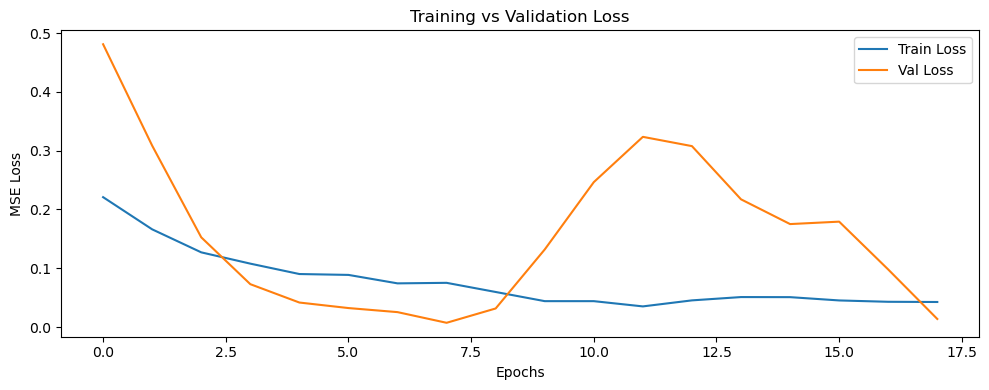

In [28]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()


In [29]:
# Prediksi pada data validasi (test_20)
y_pred_20 = model.predict(X_val_seq)

# Buat dummy array agar bisa inverse_transform
# Harus sama jumlah kolomnya dengan saat scaler digunakan
dummy_val = np.zeros((len(y_val_seq), train_80_scaled.shape[1]))
dummy_pred = np.zeros((len(y_pred_20), train_80_scaled.shape[1]))

# Masukkan nilai aktual dan prediksi ke kolom target (kolom ke-0)
dummy_val[:, 0] = y_val_seq
dummy_pred[:, 0] = y_pred_20.flatten()

# Lakukan inverse transform
y_val_inv = scaler.inverse_transform(dummy_val)[:, 0]
y_pred_inv = scaler.inverse_transform(dummy_pred)[:, 0]

# Cetak hasil
print(" y_val (real):", y_val_inv[:5])
print(" y_pred (real):", y_pred_inv[:5])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
 y_val (real): [1.81373892e+10 1.71851328e+10 1.82890716e+10 1.45300708e+10
 1.85835825e+10]
 y_pred (real): [1.63667644e+10 1.66235326e+10 1.62935960e+10 1.62510058e+10
 1.63357420e+10]


# Evaluasi

In [30]:
# Hitung MSE
mse = mean_squared_error(y_val_inv, y_pred_inv)

# Hitung MAE
mae = mean_absolute_error(y_val_inv, y_pred_inv)

# Hitung MAPE
mape = mean_absolute_percentage_error(y_val_inv, y_pred_inv) * 100  # dalam persen

# Tampilkan hasil
print("Evaluasi Model (80:20) dalam Skala Asli:")
print(f"Mean Squared Error (MSE)     : {mse:.2f}")
print(f"Mean Absolute Error (MAE)    : {mae:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Evaluasi Model (80:20) dalam Skala Asli:
Mean Squared Error (MSE)     : 2464948283320267776.00
Mean Absolute Error (MAE)    : 1421656517.19
Mean Absolute Percentage Error (MAPE): 8.32%


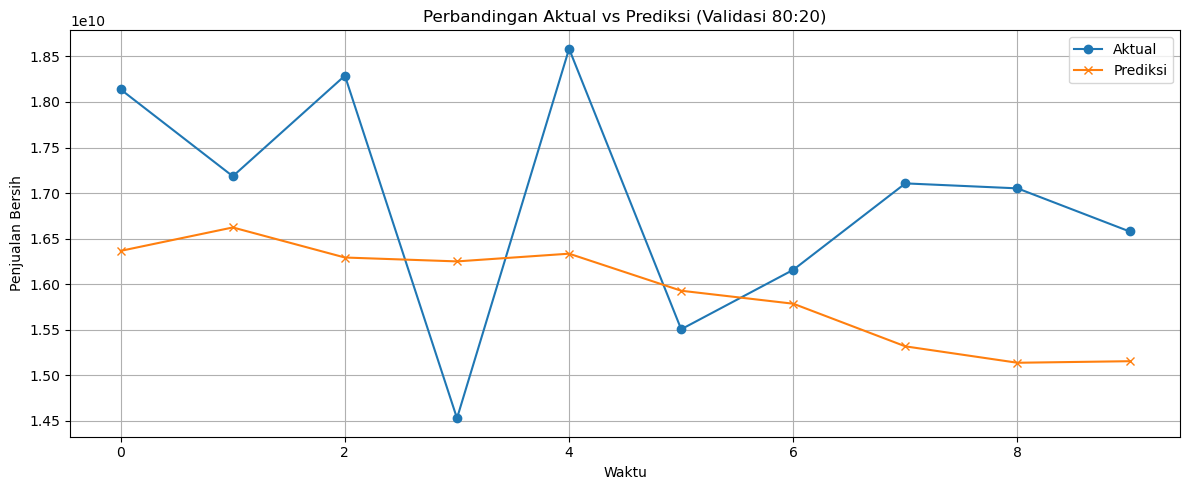

In [31]:
plt.figure(figsize=(12, 5))
plt.plot(y_val_inv, label='Aktual', marker='o')
plt.plot(y_pred_inv, label='Prediksi', marker='x')
plt.title('Perbandingan Aktual vs Prediksi (Validasi 80:20)')
plt.xlabel('Waktu')
plt.ylabel('Penjualan Bersih')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
def mse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# validasi Testing

In [35]:
# === Fungsi untuk mengembalikan skala asli dari prediksi ===
def inv_transform_80(y_preds, X_prev):
    if X_prev.ndim == 3:
        last_feats = X_prev[:, -1, :]
    else:
        last_feats = X_prev
    arr = np.hstack([y_preds.reshape(-1, 1), last_feats])
    return scaler.inverse_transform(arr)[:, 0]

# === Prediksi pada data validasi (test 20%) ===
X_val_full_80 = np.vstack([train_80_scaled[-6:], test_20_scaled])
X_val_window_feats_80 = np.array([
    X_val_full_80[i + 6 - 1, 1:]
    for i in range(len(test_20_scaled))
])

# Prediksi model
desired_steps = 3
batch_size_pred = max(1, len(X_val_seq) // desired_steps)
preds_val_80 = model.predict(X_val_seq, batch_size=batch_size_pred, verbose=1)

# Inverse transform
y_val_actual_80 = inv_transform_80(y_val_seq, X_val_window_feats_80)
y_val_pred_80   = inv_transform_80(preds_val_80.flatten(), X_val_window_feats_80)

# Tampilkan hasil
print("=== Hasil Prediksi Validasi 80:20 ===")
for i in range(len(y_val_actual_80)):
    print(f"Bulan ke-{i+1}: Aktual = {y_val_actual_80[i]:.2f}, Prediksi = {y_val_pred_80[i]:.2f}")

# === Prediksi 12 Bulan ke Depan Berdasarkan 80:20 ===
data_80_scaled_full = np.vstack([train_80_scaled, test_20_scaled])
last_window_80 = data_80_scaled_full[-6:, 1:]  # hanya ambil fitur Bulan & Lag_1

future_preds_80 = []

for i in range(12):
    X_input = last_window_80.reshape(1, 6, 2)  # (1, window, 2 fitur: Bulan & Lag_1)
    y_pred_scaled = model.predict(X_input)

    # Inverse ke skala asli
    y_pred_actual = inv_transform_80(y_pred_scaled.flatten(), last_window_80[-1, :].reshape(1, -1))[0]
    future_preds_80.append(y_pred_actual)

    # Geser window
    next_month = ((last_window_80[-1, 0] % 12) + 1)
    next_input = np.array([[next_month, y_pred_scaled[0][0]]])
    last_window_80 = np.vstack([last_window_80[1:], next_input])
# Tampilkan hasil prediksi 12 bulan ke depan
print("\n=== Prediksi 12 Bulan ke Depan ===")
for i, val in enumerate(future_preds_80, 1):
    print(f"Bulan ke-{i}: Prediksi = {val:.2f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
=== Hasil Prediksi Validasi 80:20 ===
Bulan ke-1: Aktual = 18137389202.88, Prediksi = 16366764378.16
Bulan ke-2: Aktual = 17185132762.68, Prediksi = 16623532640.75
Bulan ke-3: Aktual = 18289071590.86, Prediksi = 16293595979.16
Bulan ke-4: Aktual = 14530070820.88, Prediksi = 16251005830.77
Bulan ke-5: Aktual = 18583582492.66, Prediksi = 16335742019.86
Bulan ke-6: Aktual = 15506281002.34, Prediksi = 15929232133.65
Bulan ke-7: Aktual = 16158664602.50, Prediksi = 15786764154.39
Bulan ke-8: Aktual = 17106937752.20, Prediksi = 15318925426.67
Bulan ke-9: Aktual = 17052407543.68, Prediksi = 15138920404.91
Bulan ke-10: Aktual = 16579677096.42, Prediksi = 15155939009.29
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s

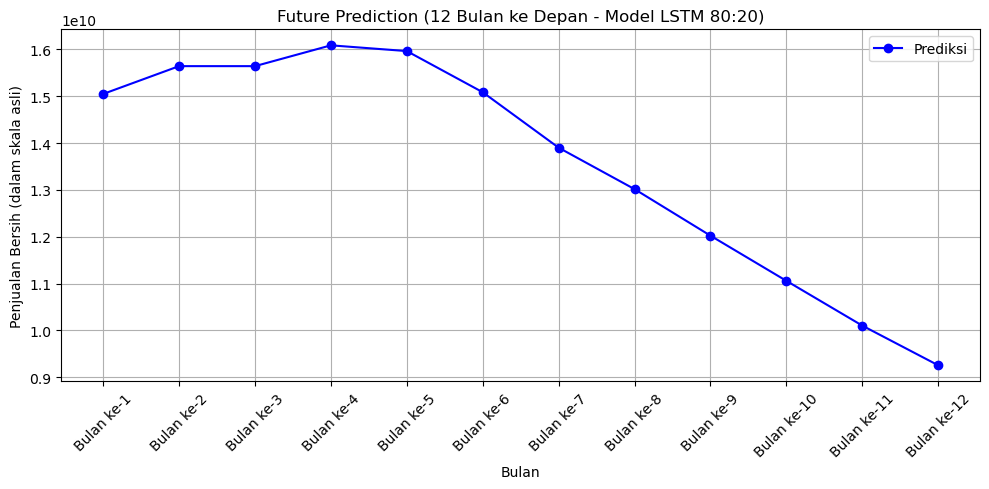

In [36]:
# Hasil prediksi 12 bulan (skema 80:20)
future_preds = [
    15049533237.28, 15643630013.59, 15643490815.65, 16087948709.68,
    15965077810.78, 15086199740.32, 13901940186.41, 13016633601.90,
    12022549356.79, 11058214803.17, 10101618991.75, 9254646523.60
]

# Label bulan ke-1 hingga ke-12
bulan_labels = [f"Bulan ke-{i}" for i in range(1, 13)]

# Visualisasikan grafik prediksi 12 bulan ke depan
plt.figure(figsize=(10, 5))
plt.plot(future_preds, marker='o', linestyle='-', color='blue', label='Prediksi')
plt.xticks(ticks=range(12), labels=bulan_labels, rotation=45)
plt.title("Future Prediction (12 Bulan ke Depan - Model LSTM 80:20)")
plt.xlabel("Bulan")
plt.ylabel("Penjualan Bersih (dalam skala asli)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# Buat dummy data untuk kebutuhan template kode ini (gantilah dengan variabel aslimu)
y_val_actual = np.array([100, 110, 120, 130, 125, 140])
y_val_pred = np.array([98, 112, 119, 128, 127, 138])


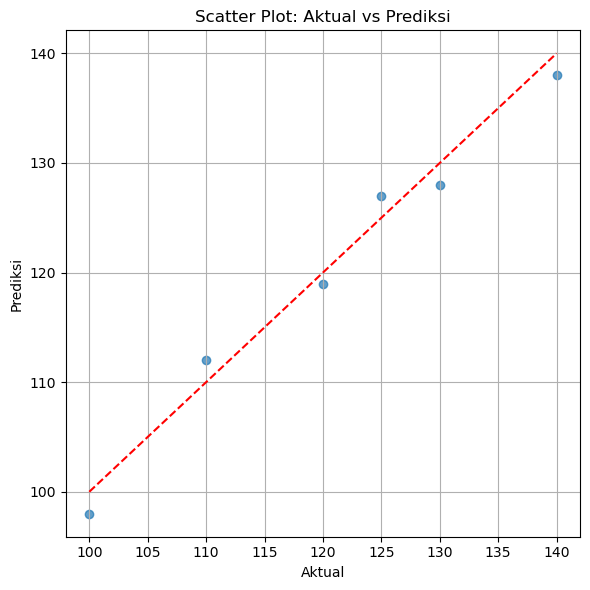

In [38]:
# Residual error
residuals = y_val_actual - y_val_pred

# Scatter plot: aktual vs prediksi
plt.figure(figsize=(6, 6))
plt.scatter(y_val_actual, y_val_pred, alpha=0.7)
plt.plot([min(y_val_actual), max(y_val_actual)], [min(y_val_actual), max(y_val_actual)], 'r--')
plt.xlabel("Aktual")
plt.ylabel("Prediksi")
plt.title("Scatter Plot: Aktual vs Prediksi")
plt.grid(True)
plt.tight_layout()
plt.show()

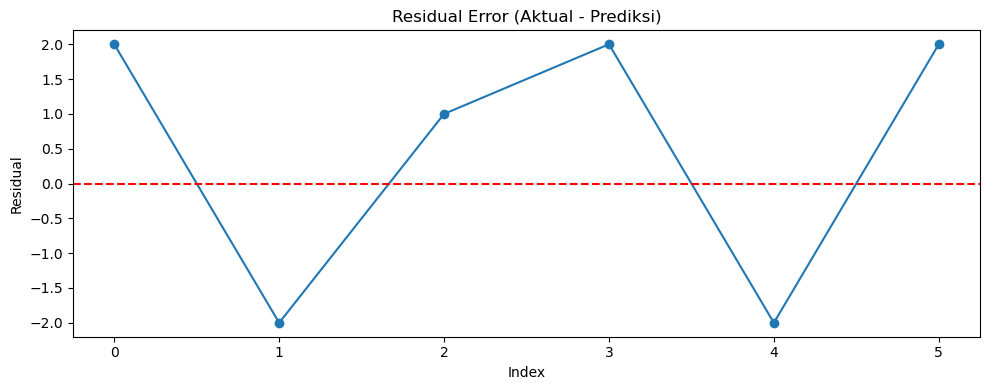

In [39]:
# Residual plot
plt.figure(figsize=(10, 4))
plt.plot(residuals, marker='o', linestyle='-')
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residual Error (Aktual - Prediksi)")
plt.xlabel("Index")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

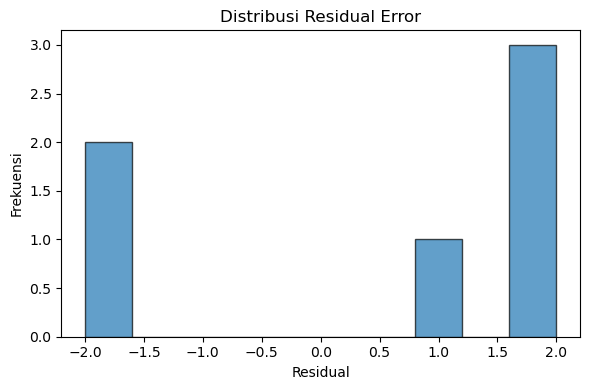

In [40]:
# Distribution of residuals
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=10, edgecolor='k', alpha=0.7)
plt.title("Distribusi Residual Error")
plt.xlabel("Residual")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

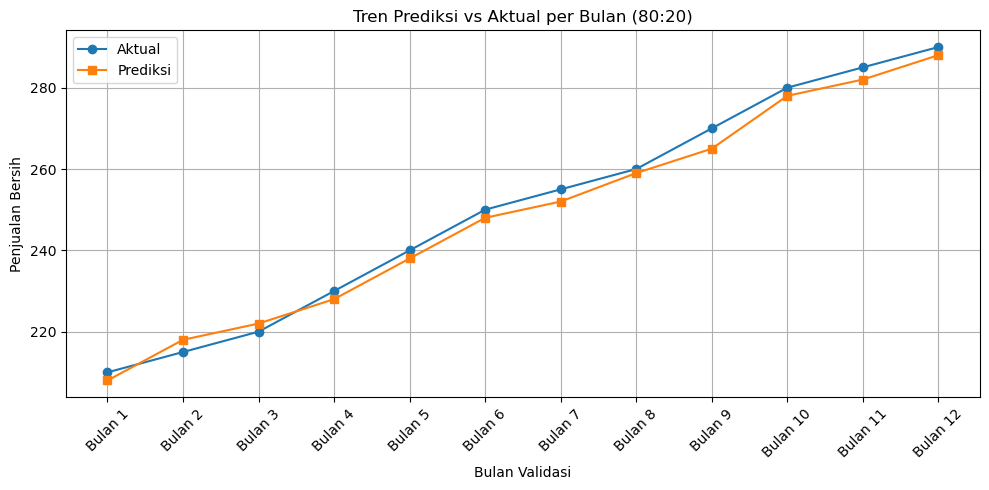

In [41]:


# Contoh data dummy (ganti dengan y_val_actual_80 dan y_val_pred_80 jika sudah tersedia di sesi kamu)
months = [f"Bulan {i+1}" for i in range(12)]
y_val_actual_80 = [210, 215, 220, 230, 240, 250, 255, 260, 270, 280, 285, 290]  # contoh
y_val_pred_80 =   [208, 218, 222, 228, 238, 248, 252, 259, 265, 278, 282, 288]  # contoh

# Plot garis tren aktual vs prediksi
plt.figure(figsize=(10, 5))
plt.plot(months, y_val_actual_80, marker='o', label='Aktual')
plt.plot(months, y_val_pred_80, marker='s', label='Prediksi')
plt.title("Tren Prediksi vs Aktual per Bulan (80:20)")
plt.xlabel("Bulan Validasi")
plt.ylabel("Penjualan Bersih")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()